**VaR under the one factor model**

Simulate the loss distribution for a portfolio of **100 obligors** under ah omogeneous one-factor threshold model.

In this model, the **default probability for each obligor is 3%**,

the **𝜌 (Korrelation) is 0.5**,

the **LGD is 0.4**,

and the **w is 0.01**.


Perform 2000 simulations of the default process to generate the loss distribution. Try to calculate the VaR analytically under the assumption of a normal distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

In [2]:
n_obligors = 100      # Anzahl Schuldner
pd = 0.03             # Default Probability
rho = 0.5             # Korrelation
lgd = 0.4             # Loss Given Default
w = 0.01              # Gewicht pro Schuldner
n_simulations = 2000  # Anzahl Simulationen

In [3]:
#default threshold under normal distribution assumption

threshold = norm.ppf(pd)

In [4]:
#simulation


losses = []

for sim in range(n_simulations):

    # Gemeinsamer Markt-Faktor
    market_factor = np.random.normal()

    total_loss = 0

    # Jeden Schuldner simulieren
    for i in range(n_obligors):

        # Individueller Faktor
        epsilon = np.random.normal()

        # Asset-Wert im One-Factor-Modell
        asset_value = (
            np.sqrt(rho) * market_factor
            + np.sqrt(1 - rho) * epsilon
        )

        # Default?
        if asset_value < threshold:
            total_loss += lgd * w

    losses.append(total_loss)

# In NumPy-Array umwandeln
losses = np.array(losses)

In [7]:
#VaR (99%) aus den Simulationen

var_99_simulated = np.percentile(losses, 99)

print(f"Simulierter VaR (99%): {var_99_simulated:.6f}")

Simulierter VaR (99%): 0.152040


In [8]:
#VaR historical

mean_loss = n_obligors * pd * lgd * w

# Varianz unter homogener Korrelation
variance_loss = (
    (n_obligors * lgd * w) ** 2
    * pd * (1 - pd)
    * rho
)

std_loss = np.sqrt(variance_loss)

# Normalverteilungs-Annahme
z_99 = norm.ppf(0.99)

var_99_analytic = mean_loss + z_99 * std_loss

In [9]:
print("Simulierter 99%-VaR:", round(var_99_simulated, 4))
print("Analytischer 99%-VaR:", round(var_99_analytic, 4))

Simulierter 99%-VaR: 0.152
Analytischer 99%-VaR: 0.1242


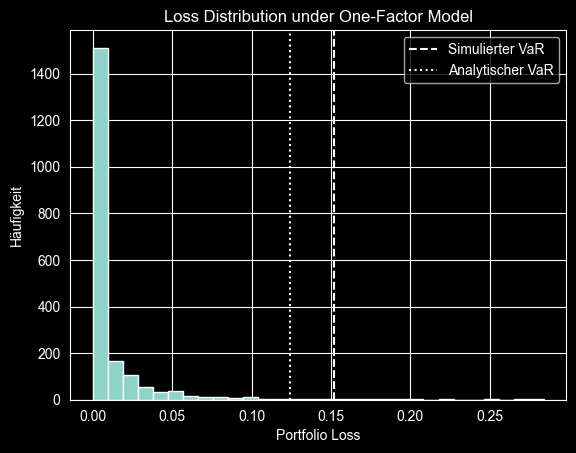

In [10]:
plt.hist(losses, bins=30)

plt.axvline(
    var_99_simulated,
    linestyle="dashed",
    label="Simulierter VaR"
)

plt.axvline(
    var_99_analytic,
    linestyle="dotted",
    label="Analytischer VaR"
)

plt.xlabel("Portfolio Loss")
plt.ylabel("Häufigkeit")
plt.title("Loss Distribution under One-Factor Model")

plt.legend()

plt.show()

Das Skript simuliert Kreditverluste in einem einfachen Kreditportfolio:

Jeder Schuldner hat:
3 % Ausfallwahrscheinlichkeit
40 % Verlust im Ausfall
Gewicht von 1 %
Alle Schuldner hängen über einen gemeinsamen Markt-Faktor zusammen.
Dadurch entstehen korrelierte Defaults.

Der Ablauf:

Markt-Schock simulieren
Für jeden Schuldner individuellen Schock simulieren
Prüfen, ob Default eintritt
Portfolioverlust berechnen
Dies 2000-mal wiederholen
Verlustverteilung plotten
99 %-VaR berechnen:
einmal aus Simulation
einmal analytisch mit Normalverteilungs-Annahme